# Figures Calcul 002 (our data)

In [1]:
# import necessary libraries
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import re
from typing import Dict, List, Tuple, Any
from matplotlib.patches import Circle

In [2]:
# File paths
data_path = "../data/002MoDe_R1.csv"
marker_path = "../data/002MoDe_R1.marker.csv"

### 1. Parse Header From Data File

In [ ]:
def parse_header(data_path: str) -> Dict[str, Any]:
    """Parses the header from the first non-empty line of the data file.
    
    - Objective:
            Extract key–value metadata stored in the first non-empty line of a CSV-like
            file. The function handles multiple formats such as `key=value`,
            `key:value`, or `key value`.

    - Inputs:
            data_path (str): Path to the data file from which the header should be read.

    - Outputs:
            Dict[str, Any]: A dictionary containing the parsed header fields.  
            Numeric values are converted to float when possible; all other values  
            remain as strings. Returns an empty dictionary if the file is not found  
             or if no header line is detected.
    """
    header: Dict[str, Any] = {}
    try:
        with open(data_path, "r", encoding="utf-8") as f:
            first_line = ""
            for line in f:
                stripped_line = line.strip()
                if stripped_line:
                    first_line = stripped_line
                    break

            if not first_line:
                return header

            for part in first_line.split(";"):
                part = part.strip()
                if not part:
                    continue

                if "=" in part:
                    k, v = part.split("=", 1)
                elif ":" in part:
                    k, v = part.split(":", 1)
                else:
                    tokens = part.split()
                    k = tokens[0]
                    v = tokens[1] if len(tokens) > 1 else ""

                k, v = k.strip(), v.strip()
                try:
                    header[k] = float(v)
                except (ValueError, TypeError):
                    header[k] = v

    except FileNotFoundError:
        print(f"Error: Data file not found at {data_path}")
        return {}

    return header

### 2. Parse Markers From Marker File

In [ ]:
def parse_markers(marker_path: str) -> Dict[str, Any]:
    """Parse a marker file to extract recording start and end timestamps.

    - Objective:
            Read a marker log file and identify the timestamps corresponding to 
            "DoRecord" and "DoPause" events. These markers define the start and end 
            of recorded segments. The function also provides the full list of markers 
            and matches each start event to its corresponding end event.

    - Inputs:
            marker_path (str): Path to the marker file. The file is expected to contain
            lines formatted with at least two comma-separated fields, where the
            second field is a timestamp.

    - Outputs:
            Dict[str, Any]: A dictionary containing:
                "start_ts" (List[int]): Sorted list of detected start timestamps.
                "end_ts" (List[int]): Sorted list of detected end timestamps.
                "pairs" (List[Tuple[int, int]]): List of matched (start, end) timestamp pairs.
                "all_markers" (List[Tuple[int, str]]): All markers found, each as (timestamp, raw_line).
      
      Raises informative exceptions if the marker file is missing or if no valid
      start/end markers can be extracted.
    """
    record_starts_raw: List[int] = []
    record_ends_raw: List[int] = []
    all_markers: List[Tuple[int, str]] = []

    try:
        with open(marker_path, "r", encoding="utf-8") as f:
            lines = f.readlines()
    except FileNotFoundError:
        raise FileNotFoundError(f"Marker file not found at {marker_path}")

    for line in lines:
        parts = line.strip().split(",")
        if len(parts) < 2:
            continue

        ts_str = parts[1].strip().replace(" ", "")
        try:
            ts = int(ts_str)
        except ValueError:
            continue

        all_markers.append((ts, line.strip()))

        if "DoCycleChange:DoRecord" in line:
            record_starts_raw.append(ts)
        elif "DoCycleChange:DoPause" in line:
            record_ends_raw.append(ts)

    if not record_starts_raw:
        raise ValueError("No 'DoRecord' events detected in the marker file.")
    if not record_ends_raw:
        raise ValueError("No 'DoPause' events detected in the marker file.")

    record_starts_raw.sort()
    record_ends_raw.sort()

    pairs: List[Tuple[int, int]] = []
    end_idx = 0
    for start_ts in record_starts_raw:
        while end_idx < len(record_ends_raw) and record_ends_raw[end_idx] < start_ts:
            end_idx += 1
        if end_idx < len(record_ends_raw):
            pairs.append((start_ts, record_ends_raw[end_idx]))
            end_idx += 1
        else:
            break

    if not pairs:
        raise RuntimeError("No valid start/end pairs found in markers.")

    return {
        "start_ts": [p[0] for p in pairs],
        "end_ts": [p[1] for p in pairs],
        "pairs": pairs,
        "all_markers": all_markers,
    }

### 3. Load Time-Series Data From CSV File

In [ ]:
def load_data(data_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Load timestamp, mouse position (x, y), and target indicator data from a CSV file.
    
    - Inputs:
            data_path (str): Path to the CSV file.

    - Outputs:
            Tuple of four np.ndarray:
                timestamps, mouse_x, mouse_y, in_target.
                Returns empty arrays if the file is not found."""
    
    timestamps: List[float] = []
    mouse_x: List[float] = []
    mouse_y: List[float] = []
    in_target: List[int] = []

    try:
        with open(data_path, "r", encoding="utf-8") as f:
            # Skip header lines until a data row is found
            for line in f:
                if (
                    line.strip()
                    and re.match(r"^-?\d+", line.strip().split(";")[0].split(",")[0])
                ):
                    parts = line.strip().split(";")[0].split(",")
                    if len(parts) >= 4:
                        try:
                            timestamps.append(float(parts[0]))
                            mouse_x.append(float(parts[1]))
                            mouse_y.append(float(parts[2]))
                            in_target.append(int(float(parts[3])))
                        except ValueError:
                            pass
                    break

            # Continue reading the rest of the file
            reader = csv.reader(f, delimiter=";")
            for row in reader:
                if len(row) >= 1 and "," in row[0]:
                    parts = row[0].split(",")
                    if len(parts) >= 4:
                        try:
                            timestamps.append(float(parts[0]))
                            mouse_x.append(float(parts[1]))
                            mouse_y.append(float(parts[2]))
                            in_target.append(int(float(parts[3])))
                        except ValueError:
                            continue

    except FileNotFoundError:
        print(f"Error: Data file not found at {data_path}")
        return np.array([]), np.array([]), np.array([]), np.array([])

    return (
        np.array(timestamps),
        np.array(mouse_x),
        np.array(mouse_y),
        np.array(in_target),
    )

In [6]:
def plot_overall_timeseries(
    time: np.ndarray,
    mouse_x: np.ndarray,
    mouse_y: np.ndarray,
    record_starts_sec: List[float],
    record_ends_sec: List[float],
) -> None:
    """Plot raw time series"""
    # Centrer les données
    plot_x = mouse_x - np.mean(mouse_x)
    plot_y = mouse_y - np.mean(mouse_y)

    # Masque des intervalles valides
    valid_mask = np.zeros_like(time, dtype=bool)
    for start, end in zip(record_starts_sec, record_ends_sec):
        valid_mask |= (time >= start) & (time <= end)

    plot_x_masked = np.copy(plot_x)
    plot_y_masked = np.copy(plot_y)
    plot_x_masked[~valid_mask] = np.nan
    plot_y_masked[~valid_mask] = np.nan

    plt.figure(figsize=(15, 6))
    plt.plot(time, plot_x_masked, ".", ms=4, color="tab:blue", label="x position")
    plt.plot(time, plot_y_masked, ".", ms=4, color="tab:orange", label="y position")

    for i, s in enumerate(record_starts_sec):
        plt.axvline(
            s,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="record start" if i == 0 else "",
        )

    for i, e in enumerate(record_ends_sec):
        plt.axvline(
            e,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label="record end" if i == 0 else "",
        )

    plt.xlim(
        min(time[0], record_starts_sec[0]) - 1,
        max(time[-1], record_ends_sec[-1]) + 1,
    )
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Raw time series data")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [7]:
def plot_record_trajectory(
    record_idx: int,
    data: Dict[str, np.ndarray],
    header: Dict[str, Any],
) -> None:
    """Plot the spatial cursor trajectory for a single recording.

    The figure shows:
    - The continuous cursor trajectory (steel-blue line).
    - Sample points classified as:
      - inside the target (green dots),
      - outside the target (red dots).
    - The target ring, drawn as a yellow annulus centered at (0, 0),
      ESTIMATED À PARTIR DES POINTS inside (in_target == 1).
    - The screen border, drawn as a magenta rectangle, using
      `screenWidth` and `screenHeight` from the header.
    """

    fig, ax = plt.subplots(figsize=(8, 5))

    x_task, y_task, in_task = data["x"], data["y"], data["in_target"]

    # Trajectoire + points
    ax.plot(x_task, y_task, "-", color="steelblue", zorder=2, lw=0.5)
    ax.scatter(
        x_task[in_task == 1],
        y_task[in_task == 1],
        color="green",
        s=10,
        zorder=3,
        lw=0.3,
    )
    ax.scatter(
        x_task[in_task == 0],
        y_task[in_task == 0],
        color="red",
        s=10,
        zorder=3,
        lw=0.8,
    )

    # distance de chaque point au centre (0,0)
    dist = np.sqrt(x_task**2 + y_task**2)

    # on garde uniquement les points "inside"
    dist_inside = dist[in_task == 1]

    if dist_inside.size > 0:
        # rayon intérieur / extérieur dérivés des points inside
        inner_r = dist_inside.min()
        outer_r = dist_inside.max()

        circle_outer = plt.Circle(
            (0, 0),
            outer_r,
            color="yellow",
            alpha=0.5,
            zorder=1,
        )
        circle_inner = plt.Circle(
            (0, 0),
            inner_r,
            color="white",
            zorder=2,
        )

        ax.add_patch(circle_outer)
        ax.add_patch(circle_inner)

    # Screen border (comme avant)
    sw, sh = header.get("screenWidth", 0), header.get("screenHeight", 0)
    ax.plot(
        [-sw / 2, sw / 2, sw / 2, -sw / 2, -sw / 2],
        [-sh / 2, -sh / 2, sh / 2, sh / 2, -sh / 2],
        color="magenta",
        lw=1.2,
        zorder=0,
    )

    # Légende personnalisée
    screen_leg = Patch(
        facecolor="none",
        edgecolor="magenta",
        linewidth=1.2,
        label="screen",
    )
    # Target dans la légende : jaune plein
    target_leg = Patch(
        facecolor="yellow",
        edgecolor="yellow",
        linewidth=0,
        label="target",
    )
    inside_leg = Line2D(
        [0],
        [0],
        marker="o",
        color="green",
        linestyle="None",
        markersize=4,
        label="inside",
    )
    outside_leg = Line2D(
        [0],
        [0],
        marker="o",
        color="red",
        linestyle="None",
        markersize=4,
        label="outside",
    )

    ax.legend(
        handles=[screen_leg, target_leg, inside_leg, outside_leg],
        loc="upper right",
    )

    ax.set_title(f"Record {record_idx}")
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    ax.axis("equal")
    ax.grid(False)

    plt.show()


In [8]:
def plot_record_temporal(record_idx: int, data: Dict[str, np.ndarray]) -> None:
    """Temporal plots (X, Y, is_inside) pour un record."""
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(f"Record {record_idx}")

    t_task, x_task, y_task, in_task = (
        data["time"],
        data["x"],
        data["y"],
        data["in_target"],
    )

    # X Position
    axes[0].plot(
        t_task,
        x_task,
        linestyle="-",
        marker="o",
        color="blue",
        label="x",
        lw=0.5,
        markersize=2,
    )
    axes[0].set_ylabel("X (pixels)")
    axes[0].legend()
    axes[0].grid(True)

    # Y Position
    axes[1].plot(
        t_task,
        y_task,
        linestyle="-",
        marker="o",
        color="orange",
        label="y",
        lw=0.5,
        markersize=2,
    )
    axes[1].set_ylabel("Y (pixels)")
    axes[1].legend()
    axes[1].grid(True)

    # In Target Flag (step)
    axes[2].step(
        t_task,
        in_task,
        linestyle="-",
        marker="o",
        where="post",
        color="green",
        label="is_inside",
        lw=0.5,
        markersize=2,
    )
    axes[2].set_ylabel("Is inside")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## The raw trajectory data

In [9]:
def plot_global_trajectory(all_records, header):
    """Plot all records superimposed as a single global trajectory with target annulus and inside points."""

    xs, ys = [], []
    for i, (_, x_rec, y_rec, _) in enumerate(all_records):
        x = np.asarray(x_rec)
        y = np.asarray(y_rec)
        if x.size == 0 or y.size == 0:
            continue
        xs.append(x)
        ys.append(y)
        if i < len(all_records) - 1:
            xs.append(np.array([np.nan]))
            ys.append(np.array([np.nan]))

    X = np.concatenate(xs) if xs else np.array([])
    Y = np.concatenate(ys) if ys else np.array([])

    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot the global trajectory
    if X.size:
        ax.plot(X, Y, '-', color='tab:blue', lw=0.9, alpha=0.95, label='trajectory', zorder=2)

    # Collect points inside the target
    inside_x = []
    inside_y = []
    for (_, x_rec, y_rec, in_rec) in all_records:
        x_a = np.asarray(x_rec)
        y_a = np.asarray(y_rec)
        in_a = np.asarray(in_rec)
        if in_a.size and np.any(in_a == 1):
            inside_x.append(x_a[in_a == 1])
            inside_y.append(y_a[in_a == 1])

    if inside_x:
        ix = np.concatenate(inside_x)
        iy = np.concatenate(inside_y)
        d = np.sqrt(ix**2 + iy**2)
        inner_r = float(d.min())
        outer_r = float(d.max())
        # Draw target annulus with red edges and no fill
        circle_outer = Circle((0, 0), outer_r, edgecolor='red', facecolor='none', label='target', lw=1.5, zorder=5)
        circle_inner = Circle((0, 0), inner_r, edgecolor='red', facecolor='none', lw=1.5, zorder=5)
        
        ax.add_patch(circle_outer)
        ax.add_patch(circle_inner)
       
       
        # Plot inside target points in green
        ax.scatter(ix, iy, color='green', s=15, label='inside target', zorder=4)

    # Optional screen border if available in header
    sw = header.get('screenWidth', None) if header else None
    sh = header.get('screenHeight', None) if header else None
    if sw and sh:
        ax.plot([-sw/2, sw/2, sw/2, -sw/2, -sw/2],
                [-sh/2, -sh/2, sh/2, sh/2, -sh/2],
                color='white', lw=1.2, zorder=0)

    # Axis limits and aspect
    if X.size:
        valid = ~np.isnan(X) & ~np.isnan(Y)
        if np.any(valid):
            m = 40
            xlim = -800, 800
            ymin, ymax = Y[valid].min() - m, Y[valid].max() + m
            ax.set_xlim(xlim)
            ax.set_ylim(ymin, ymax)

    ax.set_aspect('equal')
    ax.set_title('Raw trajectory data')
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')
    ax.grid(False)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


## The big plot

--- Header Information ---
screenWidth: 1447.0
screenHeight: 736.0
cornerX: 435.0
cornerY: 80.0
centerX: 723.0
centerY: 368.0
externalRadius: 288.0
internalRadius: 208.0
borderRadius: 1.0
cursorRadius: 16.0
indexOfDifficulty: 33.086986458020164
taskRadius: 247.5
taskTolerance: 47.0
autoStart: 3600.0
cycleMaxNumber: 6.0
cycleDuration: 20.0
software: mouseReMoCo
version: 1.3.0
task: circular
isWithLSL: false
----------------------------

--- Record Durations ---
Record 0: Start=-0.016s, End=19.997s, Duration=20.013s
Record 1: Start=40.010s, End=60.024s, Duration=20.014s
Record 2: Start=80.037s, End=100.046s, Duration=20.009s
Record 3: Start=120.060s, End=140.074s, Duration=20.014s
Record 4: Start=160.088s, End=180.104s, Duration=20.016s
Record 5: Start=200.115s, End=220.118s, Duration=20.003s
------------------------------


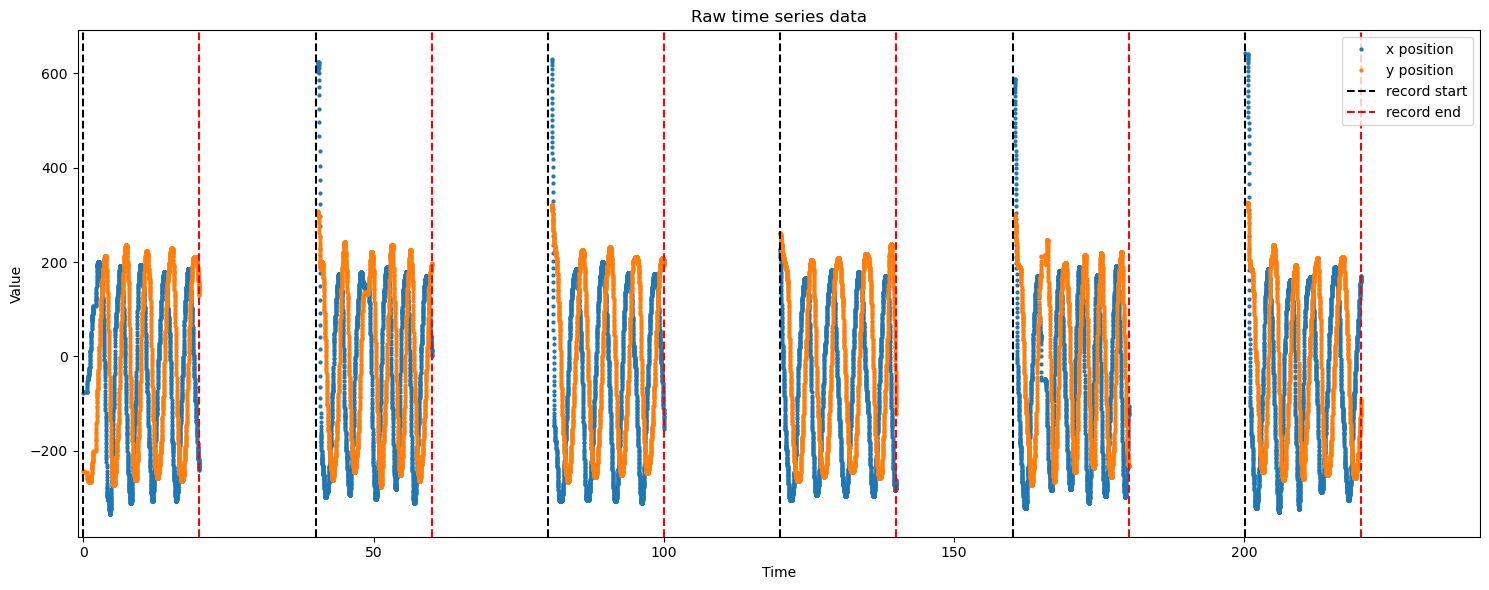


--- Global Trajectory Plot (All Records Superimposed) ---


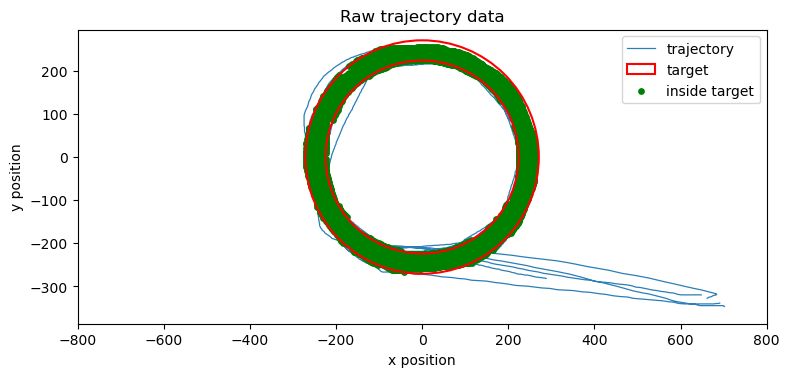


--- Processing Individual Records ---
Generating plots for Record 0...


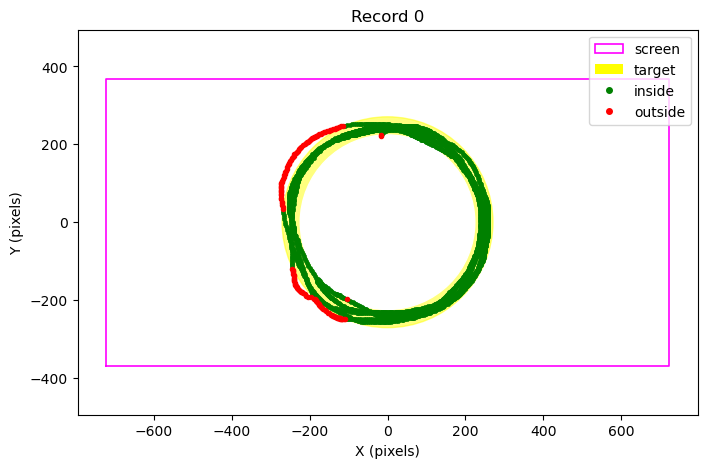

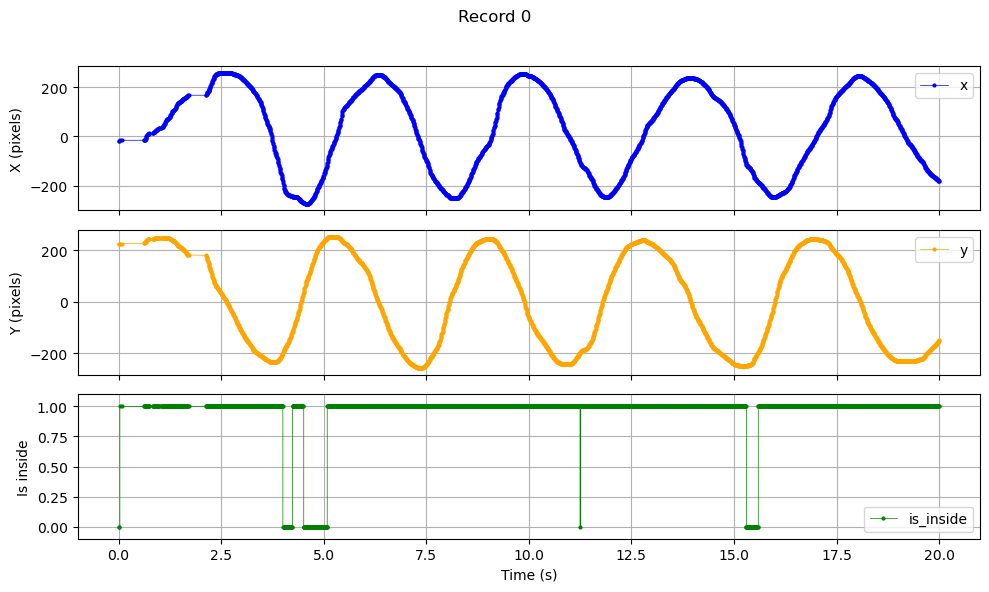

Generating plots for Record 1...


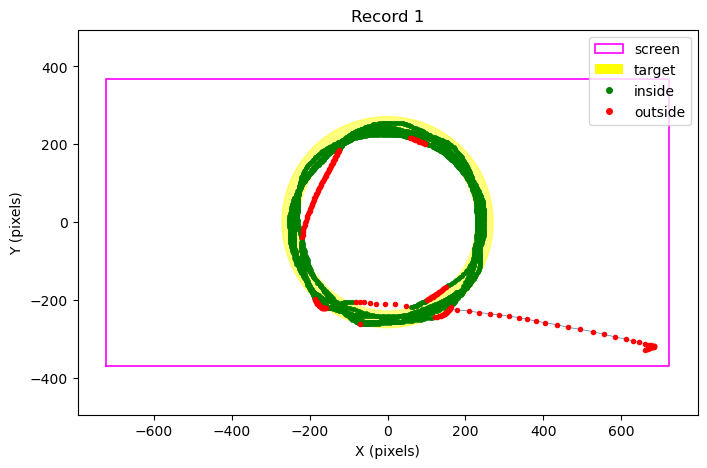

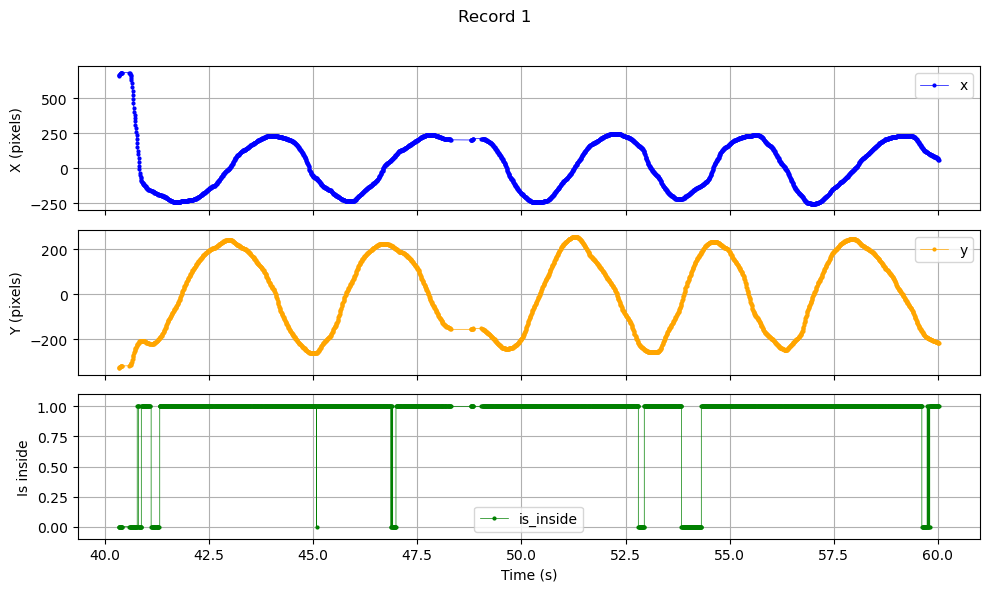

Generating plots for Record 2...


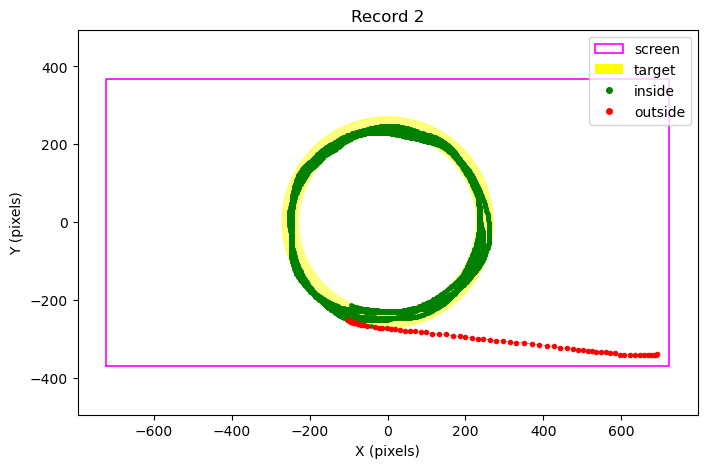

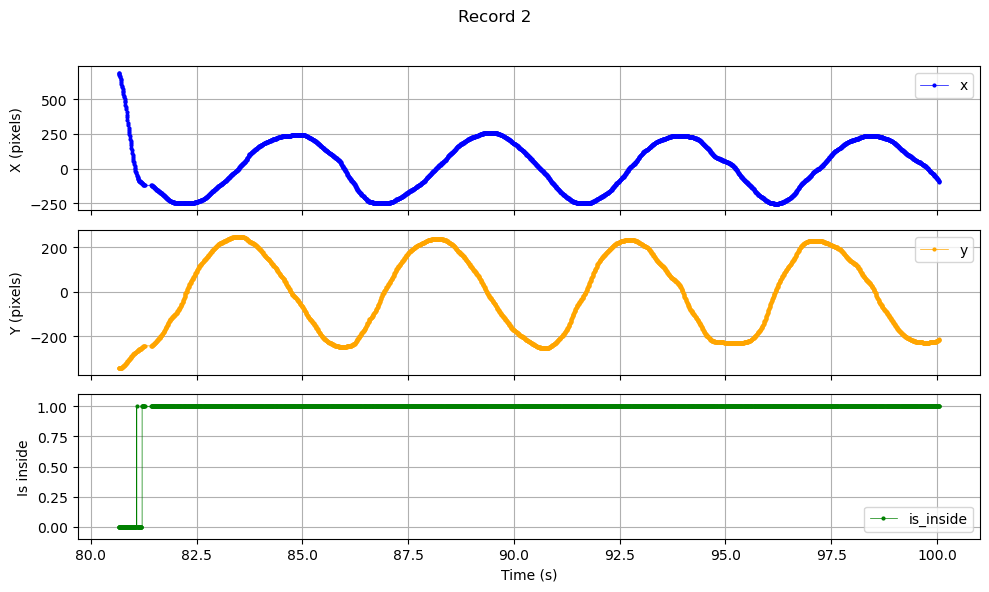

Generating plots for Record 3...


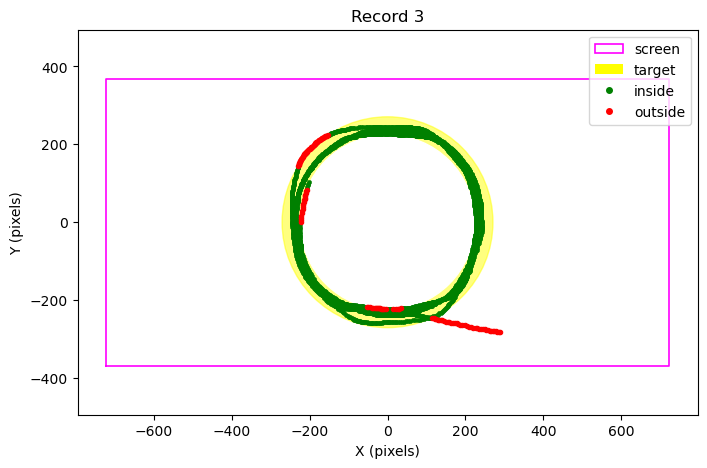

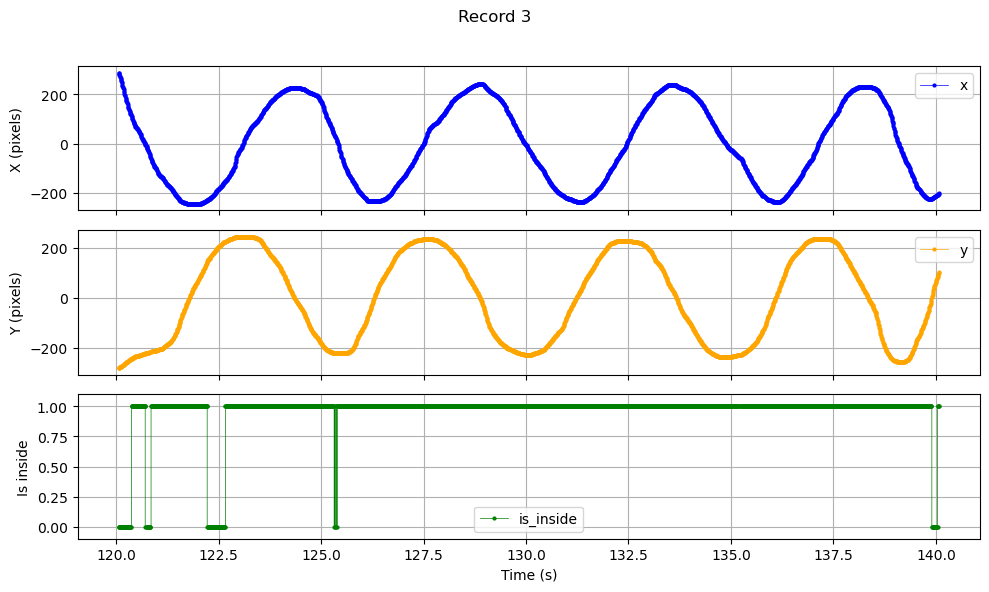

Generating plots for Record 4...


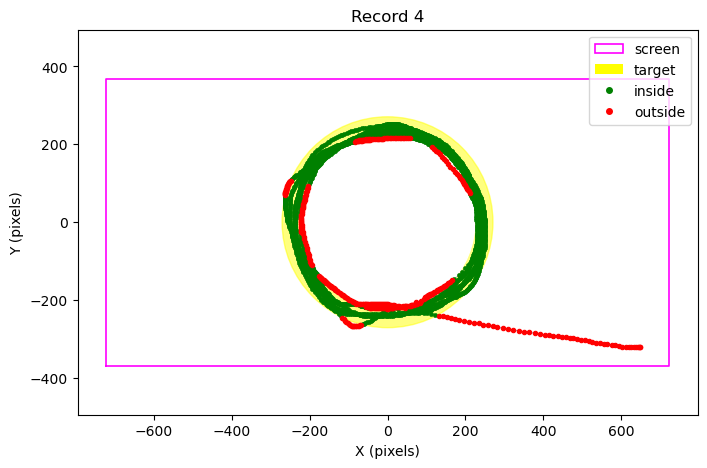

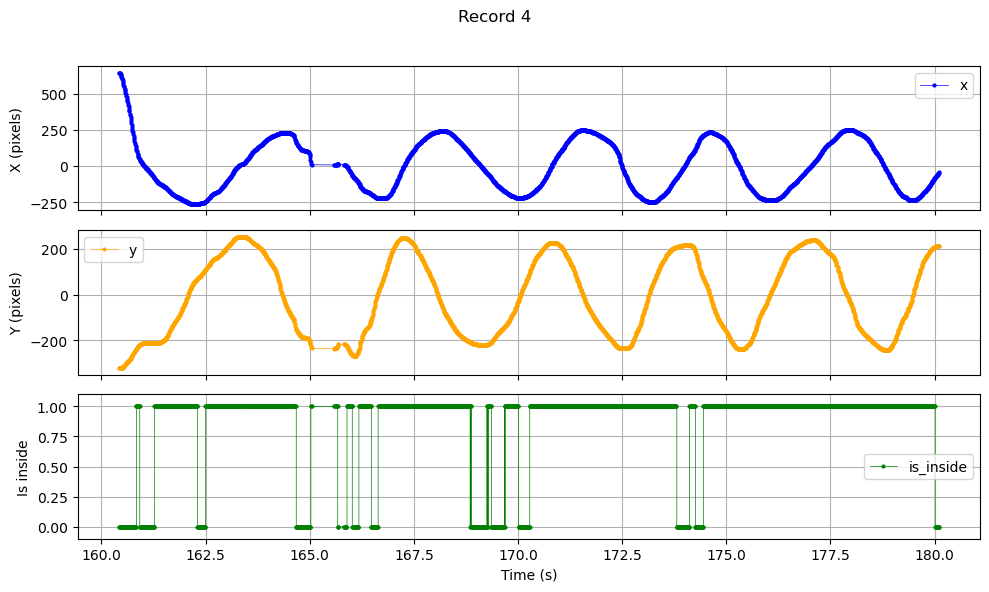

Generating plots for Record 5...


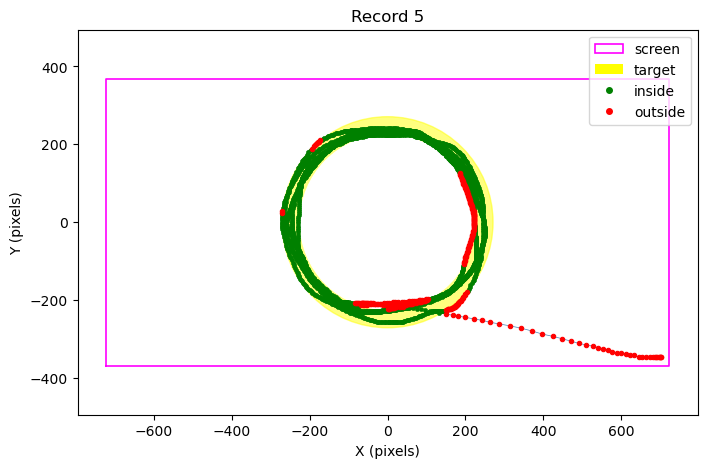

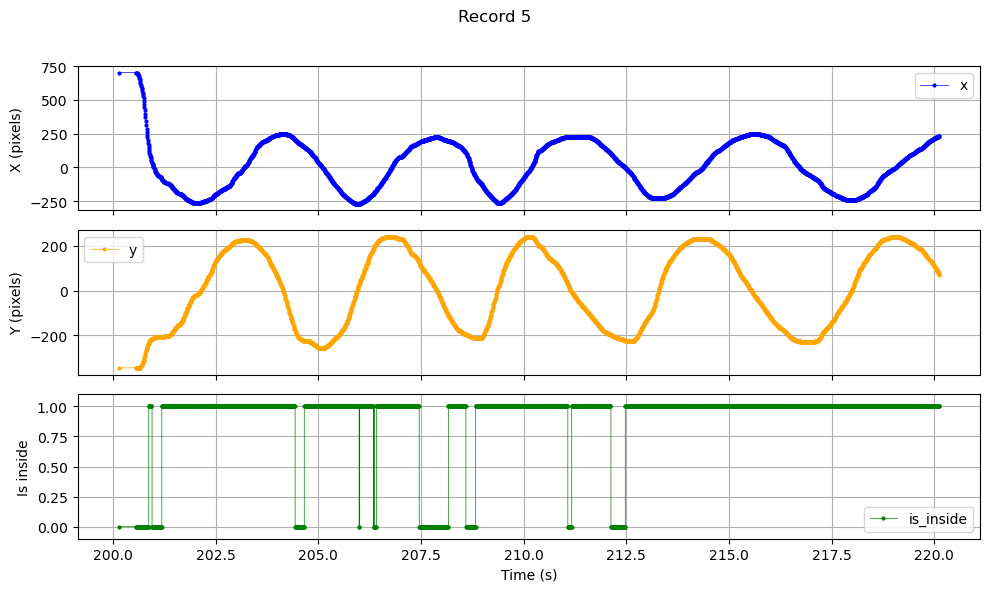


Analysis complete. Plots are displayed inline above.


In [10]:
def main() -> None:
    """Main function to run the analysis workflow."""
    try:
        header = parse_header(data_path)
        markers = parse_markers(marker_path)
        timestamps, mouse_x, mouse_y, in_target = load_data(data_path)
    except (FileNotFoundError, ValueError, RuntimeError) as e:
        print(f"An error occurred during data loading: {e}")
        return

    if timestamps.size == 0:
        print("No data was loaded. Exiting.")
        return

    print("--- Header Information ---")
    keys_to_print = [
        "screenWidth","screenHeight","cornerX","cornerY","centerX","centerY",
            "externalRadius","internalRadius","borderRadius","cursorRadius",
            "indexOfDifficulty","taskRadius","taskTolerance","autoStart",
            "cycleMaxNumber","cycleDuration","software","version","task","isWithLSL",
            "borderColor","backgroundColor","cursorColorRecord","cursorColorWait",
    ]
    for key in keys_to_print:
        if key in header:
            print(f"{key}: {header.get(key)}")
    print("-" * 28)

    t0 = timestamps[0]
    time_sec = (timestamps - t0) / 1000.0
    record_starts_sec = [(ts - t0) / 1000.0 for ts in markers["start_ts"]]
    record_ends_sec = [(ts - t0) / 1000.0 for ts in markers["end_ts"]]
    
    print("\n--- Record Durations ---")
    for i, (start, end) in enumerate(zip(record_starts_sec, record_ends_sec)):
        duration = end - start
        print(
            f"Record {i}: Start={start:.3f}s, End={end:.3f}s, Duration={duration:.3f}s"
        )
    print("-" * 30)

    plot_overall_timeseries(
        time_sec,
        mouse_x,
        mouse_y,
        record_starts_sec,
        record_ends_sec,
    )

    # Build all_records for global trajectory plot
    center_x = header.get("centerX", 0)
    center_y = header.get("centerY", 0)
    
    all_records = []
    for start_sec, end_sec in zip(record_starts_sec, record_ends_sec):
        mask = (time_sec >= start_sec) & (time_sec <= end_sec)
        if not np.any(mask):
            continue

        t_rec = time_sec[mask]
        x_rec = mouse_x[mask] - center_x
        y_rec = -(mouse_y[mask] - center_y)
        in_rec = in_target[mask]
        all_records.append((t_rec, x_rec, y_rec, in_rec))

    # Plot global trajectory (all records superimposed)
    print("\n--- Global Trajectory Plot (All Records Superimposed) ---")
    if all_records:
        plot_global_trajectory(all_records, header)

    print("\n--- Processing Individual Records ---")
    
    for i, (start_sec, end_sec) in enumerate(zip(record_starts_sec, record_ends_sec)):
        mask = (time_sec >= start_sec) & (time_sec <= end_sec)
        if not np.any(mask):
            print(f"Warning: No data found for Record {i}.")
            continue

        record_data = {
            "time": time_sec[mask],
            "x": mouse_x[mask] - center_x,
            "y": -(mouse_y[mask] - center_y),
            "in_target": in_target[mask],
        }

        print(f"Generating plots for Record {i}...")
        plot_record_trajectory(i, record_data, header)
        plot_record_temporal(i, record_data)

    print("\nAnalysis complete. Plots are displayed inline above.")


if __name__ == "__main__":
    main()